# Exploración de Series Macroeconómicas del BCRP
**Tesis:** Medición del ciclo financiero en Perú mediante técnicas de reducción dimensional y machine learning  
**Autor:** Roberto Samaniego  
**Asesor:** Dr. Sergio Camiz  
**Fecha:** 2024

---

Este notebook realiza la exploración inicial de las series macroeconómicas disponibles en el BCRP:
descarga, limpieza, visualización y análisis de correlaciones.

## 1. Librerías

In [8]:
import os
os.chdir('..')  # sube un nivel desde notebooks/ a la raíz del repo
print(f"✅ Directorio: {os.getcwd()}")

✅ Directorio: /Users/robert/Documents/tesis-ciclo-financiero-peru


In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

print('✅ Librerías cargadas')

✅ Librerías cargadas


## 2. Definición de series y descarga desde API BCRP

In [2]:
# Códigos de series del BCRP
SERIES = {
    # CRÉDITO
    'Crédito sector privado':   'PN01207PM',
    'Crédito hipotecario':      'PN01210PM',
    'Crédito consumo':          'PN01209PM',
    'Crédito en ME':            'PN01208PM',
    # TASAS
    'Tasa activa (TAMN)':       'PN07807NM',
    'Tasa referencia BCRP':     'PD04722MM',
    # TIPO DE CAMBIO
    'Tipo de cambio S//$':      'PN01246PM',
    # ACTIVIDAD
    'PBI (índice)':             'PN01773AM',
    'Demanda interna':          'PN01774AM',
}

BLOQUES = {
    'Crédito': ['Crédito sector privado', 'Crédito hipotecario', 'Crédito consumo', 'Crédito en ME'],
    'Tasas':   ['Tasa activa (TAMN)', 'Tasa referencia BCRP'],
    'TC':      ['Tipo de cambio S//$'],
    'Actividad': ['PBI (índice)', 'Demanda interna'],
}

BASE_URL = 'https://estadisticas.bcrp.gob.pe/estadisticas/series/api'

def descargar_serie(codigo, inicio='2000-1', fin='2024-12'):
    """Descarga una serie del BCRP por código."""
    url = f'{BASE_URL}/{codigo}/json/{inicio}/{fin}/ing'
    try:
        r = requests.get(url, timeout=15)
        data = r.json()
        periodos = data.get('periods', [])
        registros = []
        for p in periodos:
            valor = p['values'][0]
            try:
                valor = float(str(valor).replace(',', '.'))
            except:
                valor = None
            registros.append({'fecha': p['name'], 'valor': valor})
        df = pd.DataFrame(registros)
        df['fecha'] = pd.to_datetime(df['fecha'], format='%b.%Y', errors='coerce')
        return df.dropna(subset=['fecha']).set_index('fecha').sort_index()
    except Exception as e:
        print(f'Error en {codigo}: {e}')
        return pd.DataFrame()

# Descargar todas las series
print('Descargando series del BCRP...')
data = {}
for nombre, codigo in SERIES.items():
    df = descargar_serie(codigo)
    if not df.empty:
        data[nombre] = df['valor']
        print(f'  ✅ {nombre} — {len(df)} obs. ({df.index[0].strftime("%Y-%m")} a {df.index[-1].strftime("%Y-%m")})')

print(f'\nTotal: {len(data)} series descargadas')

Descargando series del BCRP...
  ✅ Crédito sector privado — 300 obs. (2000-01 a 2024-12)
  ✅ Crédito hipotecario — 300 obs. (2000-01 a 2024-12)
  ✅ Crédito consumo — 300 obs. (2000-01 a 2024-12)
  ✅ Crédito en ME — 300 obs. (2000-01 a 2024-12)
  ✅ Tasa activa (TAMN) — 300 obs. (2000-01 a 2024-12)
  ✅ Tasa referencia BCRP — 256 obs. (2003-09 a 2024-12)
  ✅ Tipo de cambio S//$ — 300 obs. (2000-01 a 2024-12)
  ✅ PBI (índice) — 264 obs. (2003-01 a 2024-12)
  ✅ Demanda interna — 264 obs. (2003-01 a 2024-12)

Total: 9 series descargadas


## 3. Resumen estadístico

In [6]:
# Construir DataFrame consolidado
df_all = pd.DataFrame(data)

# Resumen
resumen = pd.DataFrame({
    'Inicio':  df_all.apply(lambda x: x.dropna().index.min().strftime('%Y-%m')),
    'Fin':     df_all.apply(lambda x: x.dropna().index.max().strftime('%Y-%m')),
    'Obs':     df_all.count(),
    'Nulos%':  round(df_all.isna().sum() / len(df_all) * 100, 1),
    'Media':   round(df_all.mean(), 2),
    'Mín':     round(df_all.min(), 2),
    'Máx':     round(df_all.max(), 2),
    'Último':  round(df_all.iloc[-1], 2),
})

print('RESUMEN ESTADÍSTICO DE SERIES BCRP')
print('=' * 70)
resumen

RESUMEN ESTADÍSTICO DE SERIES BCRP


,Inicio,Fin,Obs,Nulos%,Media,Mín,Máx,Último
Crédito sector privado,2000-01,2024-12,300,0.0,3.28,2.55,4.11,3.74
Crédito hipotecario,2000-01,2024-12,300,0.0,3.28,2.55,4.11,3.73
Crédito consumo,2000-01,2024-12,300,0.0,3.28,2.55,4.11,3.74
Crédito en ME,2000-01,2024-12,300,0.0,3.28,2.55,4.10,3.73
Tasa activa (TAMN),2000-01,2024-12,300,0.0,18.99,10.49,32.37,14.88
Tasa referencia BCRP,2003-09,2024-12,256,14.7,3.75,0.25,7.75,5.00
Tipo de cambio S//$,2000-01,2024-12,300,0.0,3.28,2.55,4.11,3.73
PBI (índice),2003-01,2024-12,264,12.0,136.10,75.00,187.90,186.37
Demanda interna,2003-01,2024-12,264,12.0,144.62,68.48,227.03,227.03


## 4. Visualización de series

✅ Gráfico guardado en reports/figures/01_series_bcrp.png


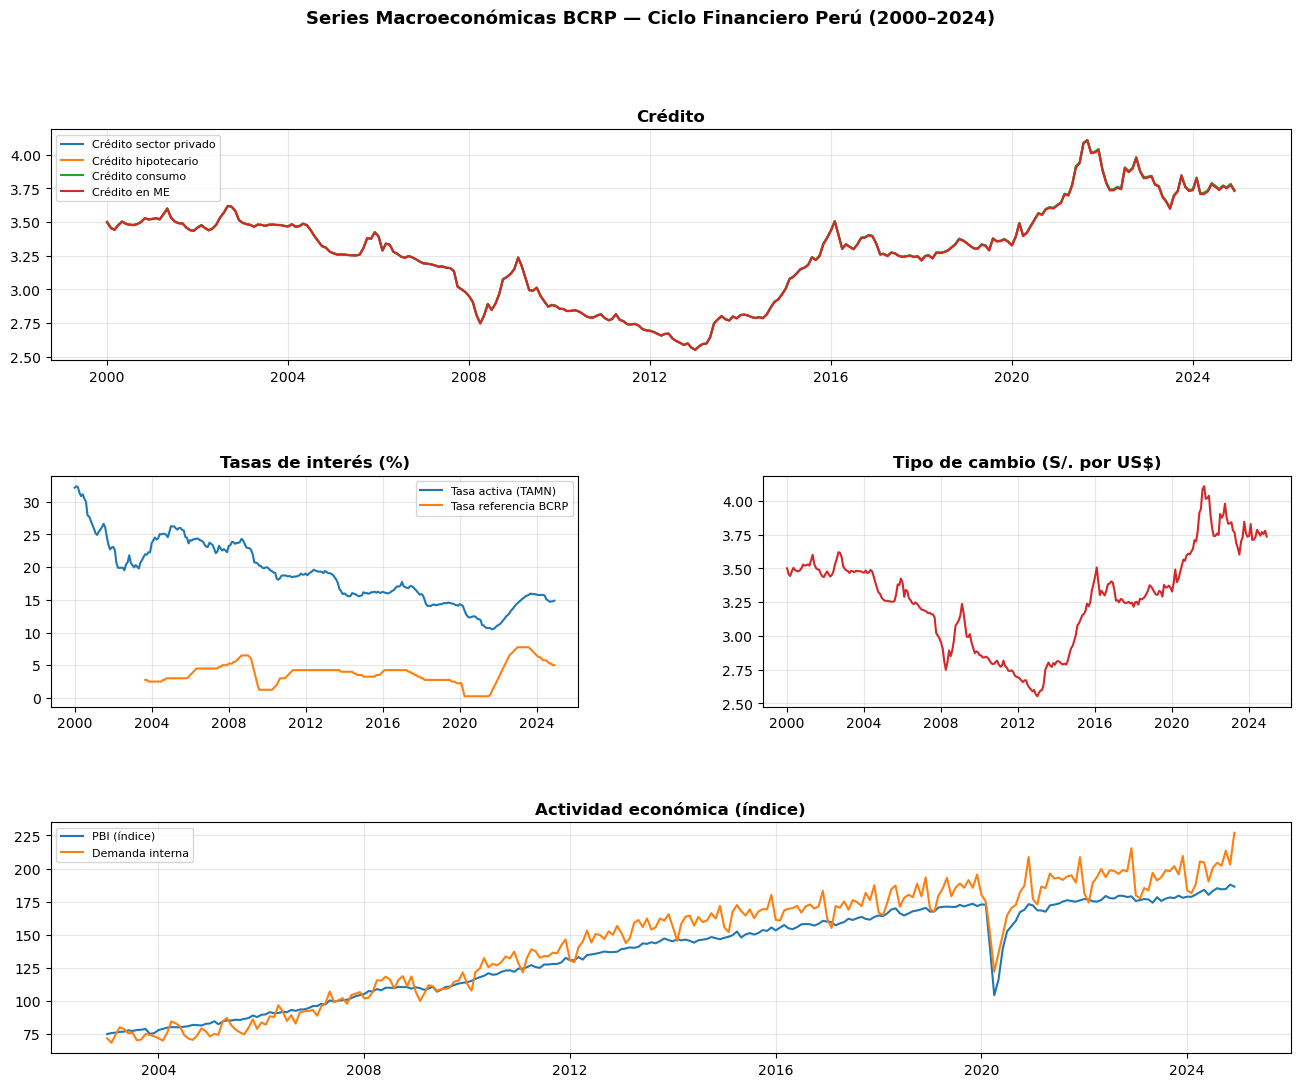

In [9]:
colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig = plt.figure(figsize=(16, 12))
fig.suptitle('Series Macroeconómicas BCRP — Ciclo Financiero Perú (2000–2024)',
             fontsize=13, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.35)

# Crédito (fila completa)
ax1 = fig.add_subplot(gs[0, :])
for i, nombre in enumerate(BLOQUES['Crédito']):
    if nombre in data:
        ax1.plot(data[nombre].index, data[nombre].values,
                label=nombre, color=colores[i], linewidth=1.5)
ax1.set_title('Crédito', fontweight='bold')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Tasas
ax2 = fig.add_subplot(gs[1, 0])
for i, nombre in enumerate(BLOQUES['Tasas']):
    if nombre in data:
        ax2.plot(data[nombre].index, data[nombre].values,
                label=nombre, color=colores[i], linewidth=1.5)
ax2.set_title('Tasas de interés (%)', fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# Tipo de cambio
ax3 = fig.add_subplot(gs[1, 1])
if 'Tipo de cambio S//$' in data:
    ax3.plot(data['Tipo de cambio S//$'].index, data['Tipo de cambio S//$'].values,
            color='#d62728', linewidth=1.5)
ax3.set_title('Tipo de cambio (S/. por US$)', fontweight='bold')
ax3.grid(True, alpha=0.3)

# Actividad económica (fila completa)
ax4 = fig.add_subplot(gs[2, :])
for i, nombre in enumerate(BLOQUES['Actividad']):
    if nombre in data:
        ax4.plot(data[nombre].index, data[nombre].values,
                label=nombre, color=colores[i], linewidth=1.5)
ax4.set_title('Actividad económica (índice)', fontweight='bold')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

plt.savefig('reports/figures/01_series_bcrp.png', dpi=150, bbox_inches='tight')
print('✅ Gráfico guardado en reports/figures/01_series_bcrp.png')
plt.show()

## 5. Matriz de correlaciones

✅ Guardado en reports/figures/01_correlaciones_bcrp.png


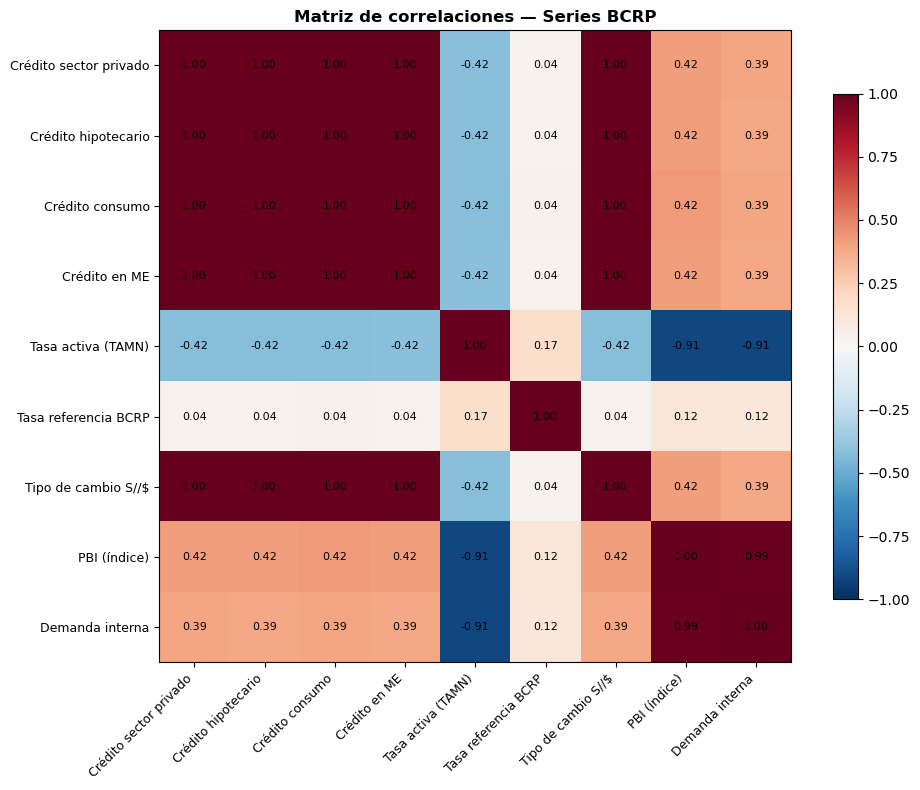

In [10]:
df_corr = df_all.dropna()
corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr.columns, fontsize=9)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}',
               ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Matriz de correlaciones — Series BCRP', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/figures/01_correlaciones_bcrp.png', dpi=150, bbox_inches='tight')
print('✅ Guardado en reports/figures/01_correlaciones_bcrp.png')
plt.show()

## 6. Guardar dataset consolidado

In [11]:
# Guardar dataset completo
df_all.to_csv('data/processed/series_bcrp_consolidado.csv')
print('✅ Dataset guardado en data/processed/series_bcrp_consolidado.csv')
print(f'   Dimensiones: {df_all.shape[0]} filas x {df_all.shape[1]} columnas')
df_all.tail()

✅ Dataset guardado en data/processed/series_bcrp_consolidado.csv
   Dimensiones: 300 filas x 9 columnas


,Crédito sector privado,Crédito hipotecario,Crédito consumo,Crédito en ME,Tasa activa (TAMN),Tasa referencia BCRP,Tipo de cambio S//$,PBI (índice),Demanda interna
fecha,,,,,,,,,
2024-08-01,3.741850,3.741325,3.745550,3.737100,14.9261,5.50,3.741325,185.173622,204.442675
2024-09-01,3.768962,3.768214,3.772143,3.764286,14.7177,5.25,3.768214,184.332773,202.193806
2024-10-01,3.754364,3.753591,3.757500,3.749682,14.7445,5.25,3.753591,184.553940,213.531675
2024-11-01,3.779135,3.778850,3.783050,3.774650,14.7810,5.00,3.778850,187.895068,203.029432
2024-12-01,3.735537,3.734895,3.740158,3.729632,14.8781,5.00,3.734895,186.365603,227.031995
